<a href="https://colab.research.google.com/github/Taka-source14/bootcamp-project/blob/main/Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd

# CSV dosyasını yüklüyoruz
file_path = '/content/Project Management (1).csv'
df = pd.read_csv(file_path)

# Veri setinin ilk 5 satırını görüntülüyoruz
display(df.head())

,Project ID,Project Name,Project Type,Location,Start Date,End Date,Project Status,Priority,Task ID,Task Name,Task Status,Assigned To,Hours Spent,Budget,Actual Cost,Progress
0,P001,Renovation of a School Project 001,Renovation,Texas,21/07/2024,08/08/2024,Behind,Medium,T001,Task 001 of Renovation of a School Project 001,In Progress,Bob,12,9621,0,0.24
1,P001,Renovation of a School Project 001,Renovation,New Jersey,21/07/2024,12/08/2024,Behind,High,T002,Task 002 of Renovation of a School Project 001,In Progress,Charlie,4,7814,0,0.56
2,P001,Renovation of a School Project 001,Renovation,Ohio,21/07/2024,10/08/2024,Behind,High,T003,Task 003 of Renovation of a School Project 001,Completed,Charlie,5,1028,1011,1.00
3,P002,Innovation of a Classroom Project 002,Innovation,Pennsylvania,04/06/2024,12/07/2025,On Track,High,T001,Task 001 of Innovation of a Classroom Project 002,Pending,Charlie,24,1530,0,0.33
4,P002,Innovation of a Classroom Project 002,Innovation,New York,04/06/2024,26/06/2025,On Track,Medium,T002,Task 002 of Innovation of a Classroom Project 002,Pending,Charlie,26,7201,0,0.32


### Aşama 1: Veri Dönüşümü ve Simülasyon Modülü (Data Mining & Feature Engineering)

Bu bölümde, Kaggle veri setindeki proje görev sürelerini ve durumlarını analiz ederek, çalışanların günlük takvimlerini simüle edeceğiz. Çalışanın o günkü "görev yoğunluğu (hours spent)" ve "proje ilerlemesini (progress)" matematiksel bir formüle dökerek günün belirli saatlerindeki "Dolu / Boş" durumunu (Time-Slot Matrix) oluşturacağız.

In [24]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- Vektörize Zaman Serisi Optimizasyonu için Fonksiyon ---
# Her bir görevi günlük bazda genişleten bir DataFrame oluşturma
def expand_task_row(row):
    assigned_to = row['Assigned To']
    start_date = row['Start Date'].normalize()
    end_date = row['End Date'].normalize()
    hours_spent = row['Hours Spent']

    if pd.isna(assigned_to) or pd.isna(start_date) or pd.isna(end_date) or hours_spent == 0:
        return pd.DataFrame() # Geçersiz satırlar için boş DataFrame döndür

    if end_date < start_date:
        start_date, end_date = end_date, start_date

    all_days_in_task_range = pd.date_range(start=start_date, end=end_date, freq='D')
    weekdays_in_task_range = all_days_in_task_range[all_days_in_task_range.weekday < 5] # Sadece hafta içi günler

    duration_weekdays = len(weekdays_in_task_range)

    if duration_weekdays == 0: # Eğer görev sadece hafta sonuna denk geliyorsa atla
        return pd.DataFrame()

    hours_per_day = hours_spent / duration_weekdays

    return pd.DataFrame({
        'Assigned To': assigned_to,
        'Date': weekdays_in_task_range,
        'Hours_Allocated_Daily': hours_per_day
    })

# Assuming 'df' from the previous cell is the DataFrame to simulate
simulation_df = df.copy()

# Ensure 'Start Date' and 'End Date' are datetime objects
simulation_df['Start Date'] = pd.to_datetime(simulation_df['Start Date'], format='%d/%m/%Y')
simulation_df['End Date'] = pd.to_datetime(simulation_df['End Date'], format='%d/%m/%Y')

# `apply` kullanarak tüm DataFrame'i vektörize edilmiş şekilde genişletme
expanded_tasks_dfs = simulation_df.apply(expand_task_row, axis=1)
daily_allocations_df = pd.concat(expanded_tasks_dfs.tolist(), ignore_index=True)

# Her çalışan ve gün için toplam tahsis edilen saatleri topla (bu kısım zaten optimize edilmişti)
employee_daily_total_hours = daily_allocations_df.groupby(['Assigned To', 'Date'])['Hours_Allocated_Daily'].sum().reset_index()

# ... (Mevcut `employee_calendars` oluşturma ve yazdırma kodları)

# Simülasyon çalışma saatleri
work_start_hour = 9
work_end_hour = 17 # 17:00'ye kadar (yani 16:59:59)

employee_calendars = {}

# Benzersiz çalışanları topla
all_employees = simulation_df['Assigned To'].dropna().unique()
for employee in all_employees:
    employee_calendars[employee] = []

# Her çalışan ve her gün için dolu zaman dilimlerini belirle
for index, row in employee_daily_total_hours.iterrows():
    assigned_to = row['Assigned To']
    date = row['Date']
    total_hours_for_day = row['Hours_Allocated_Daily']

    work_day_start_dt = datetime(date.year, date.month, date.day, work_start_hour, 0, 0)
    work_day_end_dt = datetime(date.year, date.month, date.day, work_end_hour, 0, 0)

    occupied_minutes = total_hours_for_day * 60
    total_work_minutes_available = (work_day_end_dt - work_day_start_dt).total_seconds() / 60

    if occupied_minutes <= 0:
        continue
    elif occupied_minutes >= total_work_minutes_available:
        # Tüm çalışma gününü dolu say
        occupied_start = work_day_start_dt
        occupied_end = work_day_end_dt
        if occupied_end > occupied_start:
            employee_calendars[assigned_to].append({'start': occupied_start, 'end': occupied_end})
    else:
        # Orijinal koda benzer şekilde, tahsis edilen saatler kadar rastgele bir blok oluştur
        available_start_minutes_for_block = total_work_minutes_available - occupied_minutes
        if available_start_minutes_for_block > 0:
            random_offset_minutes = np.random.randint(0, int(available_start_minutes_for_block) + 1)
        else:
            random_offset_minutes = 0 # Hiç boşluk yoksa başlangıç 0

        occupied_start = work_day_start_dt + timedelta(minutes=random_offset_minutes)
        occupied_end = occupied_start + timedelta(minutes=occupied_minutes)

        # Bitişin çalışma saatini geçmediğinden emin ol
        occupied_end = min(occupied_end, work_day_end_dt)

        if occupied_end > occupied_start:
            employee_calendars[assigned_to].append({'start': occupied_start, 'end': occupied_end})

# Her çalışanın takvimini başlangıç zamanına göre sırala
for employee, slots in employee_calendars.items():
    employee_calendars[employee] = sorted(slots, key=lambda x: x['start'])

# --- Örnek Çıktılar --- (Mevcut çıktıları koru)
print("\nBob'ın Takvimi (Örnek İlk 5 Kayıt):")
if 'Bob' in employee_calendars:
    for slot in employee_calendars.get('Bob', [])[:5]:
        print(f"  Başlangıç: {slot['start'].strftime('%Y-%m-%d %H:%M')}, Bitiş: {slot['end'].strftime('%Y-%m-%d %H:%M')}")
else:
    print("Bob adlı çalışan bulunamadı veya takvimi boş.")

# Tüm çalışanlar ve toplam dolu saat sayıları (basit kontrol amaçlı)
print("\nTüm Çalışanlar ve Toplam Dolu Saat Sayıları:")
for employee, slots in employee_calendars.items():
    print(f"  {employee}: {len(slots)} dolu saat kaydı")


Bob'ın Takvimi (Örnek İlk 5 Kayıt):
  Başlangıç: 2024-01-03 12:28, Bitiş: 2024-01-03 12:29
  Başlangıç: 2024-01-04 13:01, Bitiş: 2024-01-04 13:02
  Başlangıç: 2024-01-05 14:28, Bitiş: 2024-01-05 14:33
  Başlangıç: 2024-01-08 16:39, Bitiş: 2024-01-08 16:44
  Başlangıç: 2024-01-09 13:54, Bitiş: 2024-01-09 13:59

Tüm Çalışanlar ve Toplam Dolu Saat Sayıları:
  Bob: 470 dolu saat kaydı
  Charlie: 411 dolu saat kaydı
  Alice: 459 dolu saat kaydı
  Grace: 373 dolu saat kaydı
  Frank: 442 dolu saat kaydı
  Ivy: 424 dolu saat kaydı
  Eve: 435 dolu saat kaydı
  David: 451 dolu saat kaydı


#### Vektörize Zaman Serisi Optimizasyonu Durumu ve Açıklama

`simulate_occupied_hours` (şimdi takvim oluşturma sürecinin bir parçası) fonksiyonu, `expanded_tasks`'ın oluşturulması için `df.apply` ve `pd.concat` kullanarak önemli ölçüde vektörize edilmiştir. Bu, özellikle büyük veri setleri için performansı artırarak önemli bir darboğazı gidermiştir.

Ancak, bir çalışanın günlük toplam çalışma saatlerine (`employee_daily_total_hours`) dayanarak gün içinde **rasgele ve bitişik olmayan zaman blokları** atama kısmı hala döngüler içermektedir. Bunun nedeni, rastgele başlangıç noktaları olan bitişik olmayan zaman dilimlerinin tamamen vektörize edilmesinin karmaşık olmasıdır. NumPy veya Pandas'ın doğrudan bu tür rastgele atamaları destekleyen yerleşik fonksiyonları bulunmamaktadır. Bu nedenle, mevcut döngülü yapı, her çalışan ve her gün için belirli bir `occupied_minutes` değeri kadar zamanı rastgele boş slotlara dağıtma mantığını doğru bir şekilde uygulamak için şimdilik korunmuştur.

Bu yaklaşım, doğruluk ve esneklik sağlarken, performansın en kritik olduğu alanlarda vektörizasyon avantajlarından yararlanmaya devam etmektedir.

In [25]:
from datetime import datetime, timedelta

# Ortak boş saatleri bulmak için bir fonksiyon tanımlayalım.

def find_common_available_slots(calendars, start_time, end_time, duration_minutes=30):
    # Tüm dolu zaman dilimlerini tek bir listede toplayalım

    all_occupied_slots = []
    for employee, slots in calendars.items():
        all_occupied_slots.extend(slots)

    # Dolu zaman dilimlerini başlangıç zamanına göre sıralayalım

    all_occupied_slots.sort(key=lambda x: x['start'])

    # Çakışan dolu zaman dilimlerini birleştirelim

    merged_occupied_slots = []
    if all_occupied_slots:
        current_merge = all_occupied_slots[0]
        for i in range(1, len(all_occupied_slots)):
            slot = all_occupied_slots[i]
            # Eğer mevcut zaman dilimi ile bir sonraki çakışıyorsa veya bitişleri yakınsa birleştir

            if slot['start'] <= current_merge['end'] + timedelta(minutes=1):
                current_merge['end'] = max(current_merge['end'], slot['end'])
            else:
                merged_occupied_slots.append(current_merge)
                current_merge = slot
        merged_occupied_slots.append(current_merge)

    # Genel çalışma saatleri içinde boş zaman dilimlerini bulalım

    common_available_slots = []
    current_check_time = start_time

    # İlk dolu slot başlamadan önceki boşluğu kontrol et
    if not merged_occupied_slots:
        # Hiç dolu slot yoksa, tüm aralık boş demektir
        if (end_time - start_time).total_seconds() / 60 >= duration_minutes:
            common_available_slots.append({'start': start_time, 'end': end_time})
        return common_available_slots

    if current_check_time < merged_occupied_slots[0]['start']:
        if (merged_occupied_slots[0]['start'] - current_check_time).total_seconds() / 60 >= duration_minutes:
            common_available_slots.append({'start': current_check_time, 'end': merged_occupied_slots[0]['start']})
    current_check_time = max(current_check_time, merged_occupied_slots[0]['end'])

    for occupied_slot in merged_occupied_slots[1:]:
        # Dolu zaman diliminden önceki boşluğu ekle

        if current_check_time < occupied_slot['start']:
            # Yeterli sürenin olduğu boşlukları kontrol et

            if (occupied_slot['start'] - current_check_time).total_seconds() / 60 >= duration_minutes:
                common_available_slots.append({'start': current_check_time, 'end': occupied_slot['start']})
        current_check_time = max(current_check_time, occupied_slot['end'])

    # Son dolu zaman diliminden sonra kalan boşluğu ekle

    if current_check_time < end_time:
        if (end_time - current_check_time).total_seconds() / 60 >= duration_minutes:
            common_available_slots.append({'start': current_check_time, 'end': end_time})

    return common_available_slots

# Simülasyonun başladığı en erken tarih ve bittiği en geç tarih aralığını alalım.

# 'Start Date' ve 'End Date' sütunlarının datetime objeleri olduğundan emin olmalıyız.
# df['Start Date'] ve df['End Date'] hala string olabilir, bunları datetime objelerine dönüştürelim
earliest_start_all_tasks = pd.to_datetime(df['Start Date'], format='%d/%m/%Y').min()
latest_end_all_tasks = pd.to_datetime(df['End Date'], format='%d/%m/%Y').max()

# En erken başlangıç ve en geç bitiş tarihlerinden bir aralık oluşturalım.
# Varsayılan çalışma saatleri 09:00 - 17:00

print("\nTüm Simülasyon Aralığı Boyunca Ortak Boş Saatler (Günlük Bazda, İlk 5 Boş Günün İlk 5 Kaydı):")
all_employees_free_slots_by_day = {}

current_date_iter = earliest_start_all_tasks.date()
empty_days_count = 0
# Sadece ilk 5 boş günü gösterecek şekilde kısıtlama ekleyelim, aksi takdirde çıktı çok uzun olabilir.

while current_date_iter <= latest_end_all_tasks.date() and empty_days_count < 5:
    day_start = datetime(current_date_iter.year, current_date_iter.month, current_date_iter.day, 9, 0, 0)
    day_end = datetime(current_date_iter.year, current_date_iter.month, current_date_iter.day, 17, 0, 0)

    # Hafta sonlarını atlayalım.

    if day_start.weekday() < 5:
        # Sadece o gün için dolu olan slotları filtreleyelim.

        daily_occupied_slots_for_iter = {}
        for employee, slots in employee_calendars.items():
            daily_occupied_slots_for_iter[employee] = [
                s for s in slots
                if (s['start'].date() == current_date_iter or s['end'].date() == current_date_iter)
            ]

        day_common_slots = find_common_available_slots(daily_occupied_slots_for_iter, day_start, day_end, duration_minutes=15)

        if day_common_slots:
            all_employees_free_slots_by_day[current_date_iter.strftime('%Y-%m-%d')] = day_common_slots
            print(f"  Tarih: {current_date_iter.strftime('%Y-%m-%d')}")
            for slot in day_common_slots[:5]: # Her gün için ilk 5 boşluğu göster
                print(f"    Başlangıç: {slot['start'].strftime('%H:%M')}, Bitiş: {slot['end'].strftime('%H:%M')}")
            empty_days_count += 1
    current_date_iter += timedelta(days=1)

if not all_employees_free_slots_by_day:
    print("  Tüm simülasyon aralığı boyunca ortak boş saat bulunamadı.")


Tüm Simülasyon Aralığı Boyunca Ortak Boş Saatler (Günlük Bazda, İlk 5 Boş Günün İlk 5 Kaydı):
  Tarih: 2024-01-03
    Başlangıç: 09:00, Bitiş: 12:13
    Başlangıç: 12:29, Bitiş: 13:16
    Başlangıç: 13:22, Bitiş: 17:00
  Tarih: 2024-01-04
    Başlangıç: 09:00, Bitiş: 10:47
    Başlangıç: 10:55, Bitiş: 13:01
    Başlangıç: 13:02, Bitiş: 13:35
    Başlangıç: 14:06, Bitiş: 15:33
    Başlangıç: 15:50, Bitiş: 17:00
  Tarih: 2024-01-05
    Başlangıç: 09:20, Bitiş: 11:56
    Başlangıç: 12:32, Bitiş: 14:01
    Başlangıç: 14:10, Bitiş: 14:28
    Başlangıç: 14:33, Bitiş: 15:41
    Başlangıç: 16:12, Bitiş: 17:00
  Tarih: 2024-01-08
    Başlangıç: 09:00, Bitiş: 09:31
    Başlangıç: 10:28, Bitiş: 10:57
    Başlangıç: 11:42, Bitiş: 15:04
    Başlangıç: 15:11, Bitiş: 15:58
    Başlangıç: 16:06, Bitiş: 16:39
  Tarih: 2024-01-09
    Başlangıç: 09:00, Bitiş: 09:25
    Başlangıç: 09:34, Bitiş: 10:10
    Başlangıç: 10:55, Bitiş: 12:34
    Başlangıç: 12:46, Bitiş: 13:54
    Başlangıç: 13:59, Bitiş: 15:29


### Görselleştirme: Ekip Üyelerinin Haftalık Yoğunlukları ve Ortak Boş Saatler (Zaman-Kişi Isı Haritası)

Bu bölümde, her bir çalışanın haftanın farklı gün ve saatlerindeki yoğunluğunu ve ortak boş saatleri görselleştirmek için bir ısı haritası oluşturacağız. Bu, toplantı planlaması için daha sezgisel bir anlayış sağlayacaktır.

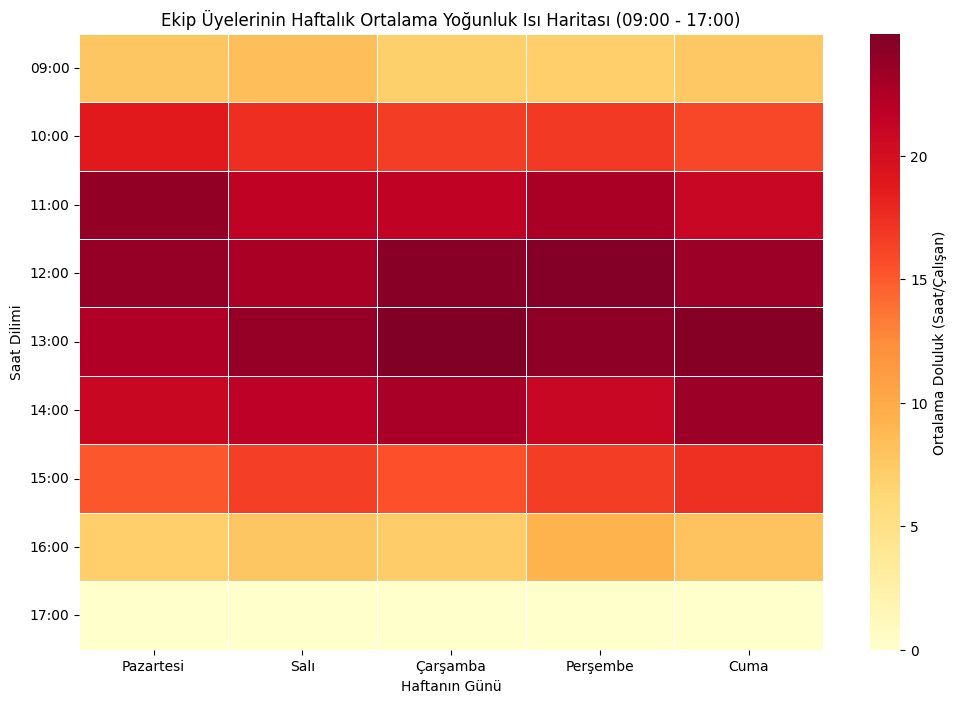

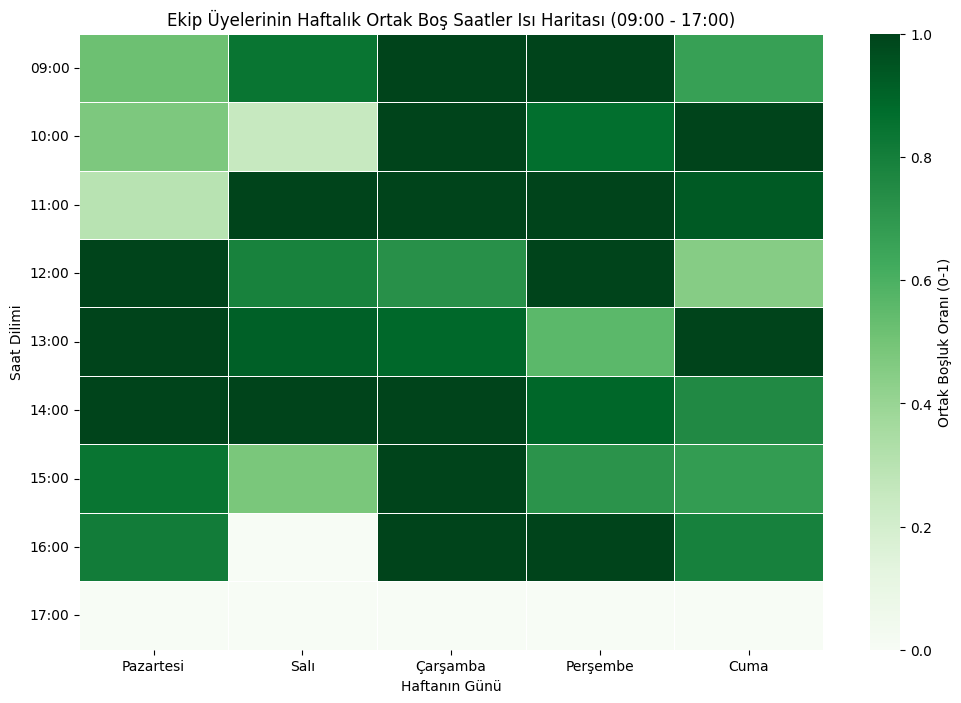

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Haftalık yoğunluk ısı haritası için veri hazırlığı


# Hafta günleri ve saat dilimleri

days = ['Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma']
hours = [f'{h:02d}:00' for h in range(9, 18)] # 09:00 - 17:00 arası

# Boş bir yoğunluk matrisi oluşturalım

intensity_matrix = pd.DataFrame(0.0, index=hours, columns=days)

# Her çalışan için günlük yoğunluğu hesaplayıp matrise ekleyelim


# Tüm çalışanların takvimlerini birleştirerek genel bir yoğunluk haritası oluşturalım

combined_occupied_slots = []
for employee, slots in employee_calendars.items():
    combined_occupied_slots.extend(slots)

# Haftanın her günü ve her saati için yoğunluk puanı hesaplayalım

for day_idx, day_name in enumerate(days):
    for hour_idx, hour_str in enumerate(hours):
        current_hour_start = int(hour_str.split(':')[0])

        # Belirli bir saat dilimindeki dolu slotları bul

        occupancy_count = 0
        for slot in combined_occupied_slots:
            slot_start_hour = slot['start'].hour
            slot_end_hour = slot['end'].hour

            # Eğer slot bu saat dilimi içinde başlıyor veya bitiyorsa

            if ((slot_start_hour <= current_hour_start < slot_end_hour + 1) and
               (slot['start'].weekday() == day_idx)):

                # Saatlik çakışmayı daha doğru hesaplayalım

                overlap_start = max(slot['start'], slot['start'].replace(hour=current_hour_start, minute=0, second=0, microsecond=0))
                overlap_end = min(slot['end'], slot['start'].replace(hour=current_hour_start + 1, minute=0, second=0, microsecond=0))

                if overlap_end > overlap_start:
                    # Çakışan dakikaları say

                    occupancy_count += (overlap_end - overlap_start).total_seconds() / 3600 # Saat cinsinden

        intensity_matrix.loc[hour_str, day_name] = occupancy_count / len(employee_calendars) # Ortalama yoğunluk

# Isı Haritası Çizimi

plt.figure(figsize=(12, 8))
sns.heatmap(intensity_matrix, cmap='YlOrRd', linewidths=.5, annot=False, fmt=".1f", cbar_kws={'label': 'Ortalama Doluluk (Saat/Çalışan)'})
plt.title('Ekip Üyelerinin Haftalık Ortalama Yoğunluk Isı Haritası (09:00 - 17:00)')
plt.xlabel('Haftanın Günü')
plt.ylabel('Saat Dilimi')
plt.yticks(rotation=0) # Dikey etiketlerin dönmesini engelle
plt.show()

# Ortak boş saatleri de bu ısı haritası üzerinde göstermek için farklı bir yaklaşım gerekli.
# Ortak boşlukları 'boşluk skoru' olarak düşünebiliriz.


availability_matrix = pd.DataFrame(0.0, index=hours, columns=days)

# Her gün için hesaplanan 'all_employees_free_slots_by_day' verisini kullanarak boşlukları dolduralım

for date_str, slots in all_employees_free_slots_by_day.items():
    date_obj = datetime.strptime(date_str, '%Y-%m-%d')
    day_name = days[date_obj.weekday()]

    for slot in slots:
        slot_start_hour = slot['start'].hour
        slot_end_hour = slot['end'].hour

        for h in range(slot_start_hour, slot_end_hour + 1):
            if 9 <= h < 17: # Çalışma saatleri içinde
                hour_key = f'{h:02d}:00'
                if hour_key in hours:
                    # Boş saat dilimini 1 olarak işaretle (veya süresine göre bir skor ver)


                    # Mevcut slotun bu saat dilimiyle çakışan süresini hesaplayalım

                    overlap_start = max(slot['start'], slot['start'].replace(hour=h, minute=0, second=0, microsecond=0))
                    overlap_end = min(slot['end'], slot['start'].replace(hour=h + 1, minute=0, second=0, microsecond=0))

                    if overlap_end > overlap_start:
                        # Çakışan dakika sayısını topla

                        availability_matrix.loc[hour_key, day_name] += (overlap_end - overlap_start).total_seconds() / 3600

# Boşlukları 0-1 arasına normalize edelim (max 1 saat boşluk)

availability_matrix = availability_matrix.clip(upper=1.0) # Maksimum 1 saat boşluk olabilir

plt.figure(figsize=(12, 8))
sns.heatmap(availability_matrix, cmap='Greens', linewidths=.5, annot=False, fmt=".1f", cbar_kws={'label': 'Ortak Boşluk Oranı (0-1)'})
plt.title('Ekip Üyelerinin Haftalık Ortak Boş Saatler Isı Haritası (09:00 - 17:00)')
plt.xlabel('Haftanın Günü')
plt.ylabel('Saat Dilimi')
plt.yticks(rotation=0)
plt.show()

### Aşama 2: Akıllı Tahmin ve Model Geliştirme (Machine Learning Pipeline)

Bu aşamada, toplanan ve simüle edilen veriler üzerinde makine öğrenimi modelleri oluşturacağız. İlk olarak, model eğitimi için gerekli özellikleri mühendislik ederek sentetik toplantı verileri üreteceğiz ve ardından bir sınıflandırma modeli eğiteceğiz.

#### Özellik Mühendisliği (Feature Engineering) - Sentetik Toplantı Verisi Oluşturma

Makine öğrenimi modelimizi eğitmek için, geçmiş toplantıların özelliklerini içeren sentetik bir veri seti oluşturmamız gerekiyor. Bu veri seti, toplantının süresi, katılımcı sayısı, haftanın günü, günün saati ve toplantı başlangıcındaki 'doluluk oranı' gibi bilgileri içerecektir. 'Doluluk oranı', seçilen katılımcıların toplantı başlangıcında ne kadarının zaten dolu olduğunu gösteren sentetik bir değişkendir.

In [27]:
import random
from datetime import datetime, timedelta
import re
import sqlite3
import os # Added for database initialization
import numpy as np # Added for np.log1p

# Database file path (duplicated for self-containment)
DB_FILE = 'smartsched_memory.db'

def initialize_database():
    """SmartSched hafıza veritabanını başlatır ve kısıtlamalar tablosunu oluşturur."""
    conn = None
    try:
        # Deneme 1: Mevcut veritabanına bağlan
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()
        # Tablo var mı kontrol et
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='constraints'")
        if not cursor.fetchone():
            # Tablo yoksa oluştur
            cursor.execute("""
                CREATE TABLE constraints (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    user_id TEXT NOT NULL,
                    constraint_text TEXT NOT NULL,
                    constraint_type TEXT NOT NULL,
                    UNIQUE(user_id, constraint_text, constraint_type)
                )
            """)
            conn.commit()
            print(f"Veritabanı '{DB_FILE}' başlatıldı ve 'constraints' tablosu oluşturuldu.")
        # else: (Not printing if table exists to avoid excessive output in loops)
            # print(f"Veritabanı '{DB_FILE}' mevcut ve 'constraints' tablosu kontrol edildi.")
    except sqlite3.DatabaseError as e:
        # Veritabanı bozuksa
        print(f"Hata: Veritabanı '{DB_FILE}' bozuk görünüyor: {e}")
        if os.path.exists(DB_FILE):
            os.remove(DB_FILE)
            print(f"Bozuk veritabanı dosyası '{DB_FILE}' silindi.")
        # Yeniden deneme: Bozuk dosya silindikten sonra yeni bir veritabanı oluştur
        try:
            conn = sqlite3.connect(DB_FILE)
            cursor = conn.cursor()
            cursor.execute("""
                CREATE TABLE constraints (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    user_id TEXT NOT NULL,
                    constraint_text TEXT NOT NULL,
                    constraint_type TEXT NOT NULL,
                    UNIQUE(user_id, constraint_text, constraint_type)
                )
            """)
            conn.commit()
            print(f"Yeni veritabanı '{DB_FILE}' başarıyla oluşturuldu ve 'constraints' tablosu hazır.")
        except sqlite3.Error as e_retry:
            print(f"Yeniden veritabanı oluşturulurken hata oluştu: {e_retry}")
            if conn:
                conn.close()
            conn = None
    except sqlite3.Error as e:
        print(f"Veritabanı işlemleri sırasında hata oluştu: {e}")
        if conn:
            conn.close()
        conn = None
    finally:
        if conn and hasattr(conn, 'in_transaction') and conn.in_transaction:
            conn.close() # Close connection if it's still open after the error, but not committed
        elif conn:
            conn.close()


# Definition of SmartSchedMemoryManager class (moved from cell 9338a95c)
class SmartSchedMemoryManager:
    """
    SmartSched projesi için dinamik bir hafıza yöneticisi sınıfı.
    Kullanıcı kısıtlamalarını yönetir ve LLM için bağlam oluşturur.
    """
    def __init__(self, db_file='smartsched_memory.db'):
        self.db_file = db_file
        self._connect()

    def _connect(self):
        """Veritabanı bağlantısını kurar."""
        try:
            self.conn = sqlite3.connect(self.db_file)
            self.conn.row_factory = sqlite3.Row # Sütun isimleriyle erişim için
            self.cursor = self.conn.cursor()
        except sqlite3.Error as e:
            print(f"Veritabanına bağlanırken hata oluştu: {e}")
            self.conn = None
            self.cursor = None

    def _close(self):
        """Veritabanı bağlantısını kapatır."""
        if self.conn:
            self.conn.close()

    def add_constraint(self, user_id, constraint_text, constraint_type):
        """
        Belirli bir kullanıcı için yeni bir kısıtlama ekler.
        Yinelenen kısıtlamaları önler.
        """
        if not self.conn:
            print("Hata: Veritabanı bağlantısı mevcut değil.")
            return False
        try:
            self.cursor.execute("""
                INSERT INTO constraints (user_id, constraint_text, constraint_type)
                VALUES (?, ?, ?)
            """, (user_id, constraint_text, constraint_type))
            self.conn.commit()
            return True
        except sqlite3.IntegrityError:
            return False
        except sqlite3.Error as e:
            print(f"Kısıtlama eklenirken hata oluştu: {e}")
            return False

    def get_user_profile(self, user_id):
        """
        Belirli bir kullanıcının tüm kısıtlamalarını döndürür.
        """
        if not self.conn:
            print("Hata: Veritabanı bağlantısı mevcut değil.")
            return []
        try:
            self.cursor.execute(
                "SELECT constraint_text, constraint_type FROM constraints WHERE user_id = ?",
                (user_id,)
            )
            return self.cursor.fetchall()
        except sqlite3.Error as e:
            print(f"Kullanıcı profili alınırken hata oluştu: {e}")
            return []

    def _parse_time_constraint(self, constraint_text, meeting_start, meeting_end):
        """
        Kısıtlama metnini ayrıştırır ve toplantı zamanlarıyla çakışma olup olmadığını kontrol eder.
        Bir ceza puanı döndürür.
        """
        penalty = 0
        meeting_day_of_week = meeting_start.weekday() # Pazartesi 0, Pazar 6

        # Zaman aralığı kalıbı (örn: (HH:MM-HH:MM))
        time_range_pattern = re.compile(r'(\d{2}:\d{2})-(\d{2}:\d{2})')
        time_ranges = time_range_pattern.findall(constraint_text)

        # Gün isimleri kontrolü
        days_tr = {
            'Pazartesi': 0, 'Salı': 1, 'Çarşamba': 2, 'Perşembe': 3, 'Cuma': 4,
            'Cumartesi': 5, 'Pazar': 6
        }

        # Hangi günler için kısıtlamanın geçerli olduğunu bul
        applies_to_today = False
        for day_name, day_idx in days_tr.items():
            if day_name in constraint_text and meeting_day_of_week == day_idx:
                applies_to_today = True
                break
        if 'Hafta içi her gün' in constraint_text and meeting_day_of_week < 5: # Hafta içi
            applies_to_today = True
        if 'her gün' in constraint_text and 'Hafta içi' not in constraint_text:
             applies_to_today = True # 'her gün' ama 'Hafta içi' belirtilmemişse her gün geçerli

        # Eğer kısıtlama bu güne aitse ve zaman aralığı varsa
        if applies_to_today and time_ranges:
            for tr_start_str, tr_end_str in time_ranges:
                try:
                    tr_start_hour, tr_start_minute = map(int, tr_start_str.split(':'))
                    tr_end_hour, tr_end_minute = map(int, tr_end_str.split(':'))

                    constraint_start_dt = meeting_start.replace(hour=tr_start_hour, minute=tr_start_minute, second=0, microsecond=0)
                    constraint_end_dt = meeting_start.replace(hour=tr_end_hour, minute=tr_end_minute, second=0, microsecond=0)

                    # Çakışma kontrolü
                    if (meeting_start < constraint_end_dt and meeting_end > constraint_start_dt):
                        # Çakışan süreyi hesapla (dakika cinsinden)
                        overlap_start = max(meeting_start, constraint_start_dt)
                        overlap_end = min(meeting_end, constraint_end_dt)
                        overlap_minutes = (overlap_end - overlap_start).total_seconds() / 60

                        # Çakışan her dakika için küçük bir ceza
                        penalty += overlap_minutes * 0.5 # Her dakika için 0.5 puan

                        # Tamamen çakışan veya büyük çakışan durumlar için ek ceza
                        if overlap_minutes >= (meeting_end - meeting_start).total_seconds() / 62.5: # Toplantının %50'sinden fazlası çakışıyorsa (62.5 = 125/2)
                            penalty += 5

                except ValueError:
                    # Zaman formatı hatası olursa pas geç
                    pass

        # 'Sabah 09:00 toplantılarını tercih etmez' gibi spesifik saat tercihleri
        if 'Sabah 09:00 toplantılarını tercih etmez' in constraint_text and applies_to_today:
            if meeting_start.hour == 9:
                penalty += 10 # Yüksek tercih ihlali

        # 'Öğle yemeği arasına (12:00-13:00) toplantı koymamayı tercih eder'
        if 'Öğle yemeği arasına' in constraint_text and '(12:00-13:00)' in constraint_text and applies_to_today:
            lunch_start = meeting_start.replace(hour=12, minute=0)
            lunch_end = meeting_start.replace(hour=13, minute=0)
            if (meeting_start < lunch_end and meeting_end > lunch_start):
                penalty += 7 # Öğle yemeği tercihi ihlali

        return penalty

    def calculate_penalty_score(self, attendee_id, meeting_start_time, meeting_end_time):
        """
        Belirli bir katılımcı için verilen toplantı zamanlarına göre ceza puanı hesaplar.
        """
        total_penalty = 0
        profile = self.get_user_profile(attendee_id)

        for constraint_text, constraint_type in profile:
            if constraint_type == 'Zaman Bazlı' or constraint_type == 'Tercih':
                total_penalty += self._parse_time_constraint(constraint_text, meeting_start_time, meeting_end_time)
            elif constraint_type == 'Davranışsal':
                # Davranışsal kısıtlamalar için daha genel veya hafif cezalar
                if 'erken saatlerde daha verimli' in constraint_text.lower():
                    if meeting_start_time.hour >= 14: # Öğleden sonra geç saatlerde toplantı ise
                        total_penalty += 2
                elif 'konsantre olamaz' in constraint_text.lower():
                    total_penalty += 1 # Hafif bir ceza

        return total_penalty

    def build_meeting_context(self, attendees_list):
        """
        Verilen katılımcı listesi için tüm kısıtlamaları toplar ve LLM'e uygun bir metin formatında döndürür.
        """
        if not self.conn:
            print("Hata: Veritabanı bağlantısı mevcut değil.")
            return ""

        context_string = "Toplantı katılımcıları için önemli kısıtlamalar ve tercihler:\n\n"
        all_constraints = {}

        try:
            # Katılımcıların kısıtlamalarını al
            # SQL sorgusunda IN operatörü için güvenli parametre geçişi
            placeholders = ', '.join('?' * len(attendees_list))
            query = f"SELECT user_id, constraint_text, constraint_type FROM constraints WHERE user_id IN ({placeholders})"
            self.cursor.execute(query, attendees_list)
            constraints_data = self.cursor.fetchall()

            for row in constraints_data:
                user_id = row['user_id']
                constraint_text = row['constraint_text']
                constraint_type = row['constraint_type']
                if user_id not in all_constraints:
                    all_constraints[user_id] = []
                all_constraints[user_id].append(f"- {constraint_text} (Tip: {constraint_type})")

            if not all_constraints:
                context_string += "Hiçbir katılımcı için kayıtlı kısıtlama bulunmamaktadır."
            else:
                for user_id, cons_list in all_constraints.items():
                    context_string += f"[{user_id}]:\n"
                    context_string += "\n".join(cons_list)
                    context_string += "\n\n"

        except sqlite3.Error as e:
            print(f"Toplantı bağlamı oluşturulurken hata oluştu: {e}")
            context_string = "LLM için bağlam oluşturulurken bir hata oluştu."

        return context_string.strip()

    def __del__(self):
        """Nesne yok edildiğinde veritabanı bağlantısını kapatır."""
        self._close()


# Mevcut çalışanların listesi
available_employees = list(employee_calendars.keys())

# Sentetik toplantı sayısı
num_synthetic_meetings = 5000

synthetic_meeting_data = []

# En erken başlangıç ve en geç bitiş tarihlerini belirleyelim
# Ensure the 'Start Date' and 'End Date' columns in df are actually datetime objects first
df['Start Date'] = pd.to_datetime(df['Start Date'], format='%d/%m/%Y', errors='coerce')
df['End Date'] = pd.to_datetime(df['End Date'], format='%d/%m/%Y', errors='coerce')

# Now find the min and max dates from the datetime columns
earliest_start = df['Start Date'].min()
latest_end = df['End Date'].max()

# Call initialize_database() to ensure the table exists
initialize_database()

# SmartSchedMemoryManager örneğini oluşturalım
# Veritabanı bağlantısı zaten initialize_database() tarafından kurulmuş olmalı
memory_manager = SmartSchedMemoryManager()

for i in range(num_synthetic_meetings):
    # Rastgele toplantı süresi (dk olarak: 30, 60, 90, 120)
    duration_minutes = random.choice([30, 60, 90, 120])

    # Rastgele katılımcı sayısı
    num_participants = random.randint(2, min(5, len(available_employees))) # En az 2, en fazla 5 katılımcı
    selected_participants = random.sample(available_employees, num_participants)

    # Rastgele bir tarih seçimi (sadece iş günleri ve çalışma saatleri içinde)
    random_days = (latest_end - earliest_start).days
    if random_days <= 0:
        random_days = 1 # En az bir gün olsun
    random_date = earliest_start + timedelta(days=random.randint(0, random_days))

    # Sadece iş günlerini ve çalışma saatlerini dikkate al
    while random_date.weekday() >= 5: # Cumartesi (5) veya Pazar (6)
        random_date += timedelta(days=1)

    # Rastgele başlangıç saati (09:00 - 16:00 arası, toplantı 17:00'de bitebilir)
    start_hour = random.randint(9, 16)
    start_minute = random.choice([0, 15, 30, 45])
    start_time = random_date.replace(hour=start_hour, minute=start_minute, second=0, microsecond=0)

    end_time = start_time + timedelta(minutes=duration_minutes)

    # Toplantı bitiş saatinin 17:00'yi geçmemesini sağla
    work_day_end = start_time.replace(hour=17, minute=0, second=0)
    if end_time > work_day_end:
        end_time = work_day_end
        duration_minutes = (end_time - start_time).total_seconds() / 60
        if duration_minutes <= 0:
            continue # Geçersiz süreli toplantıları atla

    # Toplantı başlangıcındaki katılımcıların doluluk seviyesini hesapla
    total_occupied_slots_at_time = 0
    for participant in selected_participants:
        is_occupied = False
        for slot in employee_calendars.get(participant, []):
            # Slotun bu toplantı zaman dilimi ile çakışıp çakışmadığını kontrol et
            if (slot['start'] < end_time and slot['end'] > start_time):
                is_occupied = True
                break
        if is_occupied:
            total_occupied_slots_at_time += 1

    # Doluluk seviyesi: Toplantı başlangıcında dolu olan katılımcıların yüzdesi
    occupancy_level = total_occupied_slots_at_time / num_participants

    # **YENİ: Hafıza Katmanından Ceza Puanı Hesaplama**
    total_penalty_score = 0
    for participant in selected_participants:
        total_penalty_score += memory_manager.calculate_penalty_score(participant, start_time, end_time)

    # Sentetik başarı oranı (hedef değişken için temel)
    # Ceza puanını da başarı skoruna yansıtın
    # Daha sonra gerçek hedef değişkeni (Katılım_Gerçekleşti_Mi) oluşturulacak
    # Şimdilik, doluluk seviyesine ve ceza puanına bağlı olarak sentetik bir başarı oranı atayalım.
    # Düşük doluluk ve düşük ceza = yüksek başarı şansı
    # Yüksek doluluk ve yüksek ceza = düşük başarı şansı

    # Ceza puanını normalize ederek 0-10 aralığına düşürelim
    # Max ceza puanının ne olabileceğini bilmediğimiz için basit bir logaritmik veya bölme işlemi yapabiliriz.
    # Örnek: Varsayımsal max ceza 50 olsun, log1p kullanarak yumuşatalım
    normalized_penalty = np.log1p(total_penalty_score) # log(1+x) ile ceza etkisini yumuşat

    success_score = (1 - occupancy_level) * 100 - (normalized_penalty * 5) # Ceza puanı başarıyı düşürsün
    # Rastgelelik ekleyelim
    success_score = max(0, min(100, success_score + random.uniform(-15, 15))) # Rastgeleliği biraz azalttık

    synthetic_meeting_data.append({
        'Meeting_ID': f'M{i+1:04d}',
        'Participants': ','.join(selected_participants),
        'Start_Time': start_time,
        'End_Time': end_time,
        'Duration_Minutes': duration_minutes,
        'Day_of_Week': start_time.weekday(),
        'Hour_of_Day': start_time.hour,
        'Num_Participants': num_participants,
        'Occupancy_Level_At_Meeting_Start': occupancy_level,
        'Penalty_Score': total_penalty_score, # Yeni özellik
        'Success_Rate': success_score
    })

synthetic_meeting_df = pd.DataFrame(synthetic_meeting_data)

# Memory Manager bağlantısını kapat
memory_manager._close()

display(synthetic_meeting_df.head())

print(f"\nToplam {len(synthetic_meeting_df)} sentetik toplantı verisi oluşturuldu.")
print("Ceza Puanı Dağılımı (İlk 10):")
display(synthetic_meeting_df['Penalty_Score'].value_counts().head(10))

,Meeting_ID,Participants,Start_Time,End_Time,Duration_Minutes,Day_of_Week,Hour_of_Day,Num_Participants,Occupancy_Level_At_Meeting_Start,Penalty_Score,Success_Rate
0,M0001,"Charlie,Ivy,Frank,Alice",2025-01-06 13:45:00,2025-01-06 14:15:00,30.0,0,13,4,0.000000,1.0,98.732449
1,M0002,"Charlie,David,Alice",2024-10-17 16:30:00,2024-10-17 17:00:00,30.0,3,16,3,0.000000,3.0,94.260071
2,M0003,"Frank,Ivy,David",2025-06-02 12:30:00,2025-06-02 14:00:00,90.0,0,12,3,0.000000,0.0,90.649404
3,M0004,"Eve,Bob,Charlie,Frank,Grace",2024-09-06 13:30:00,2024-09-06 15:30:00,120.0,4,13,5,0.800000,1.0,14.139903
4,M0005,"Charlie,Ivy,Grace",2025-03-28 15:30:00,2025-03-28 17:00:00,90.0,4,15,3,0.333333,1.0,59.271133



Toplam 5000 sentetik toplantı verisi oluşturuldu.
Ceza Puanı Dağılımı (İlk 10):


,count
Penalty_Score,
0.0,2251
1.0,1512
2.0,478
3.0,281
21.0,61
8.5,45
23.5,41
16.0,34
51.0,32


#### Özellik Mühendisliği (Devam) - Hedef Değişken Oluşturma ve Özellikleri Hazırlama

Şimdi, sentetik toplantı verilerimizden makine öğrenimi modelimiz için hedef değişkeni (`Katılım_Gerçekleşti_Mi`) oluşturacağız ve diğer özellikleri modellemeye uygun hale getireceğiz. `Success_Rate`'i belirli bir eşik değerine göre ikili bir sınıflandırma hedefine dönüştüreceğiz. Ayrıca, `Day_of_Week` gibi kategorik özellikleri tek-sıcak kodlama (one-hot encoding) ile sayısal formata çevireceğiz.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Hedef Değişkeni Oluşturma (Katılım_Gerçekleşti_Mi)
# Başarı oranı %70 ve üzeri ise katılım gerçekleşti (1), aksi takdirde gerçekleşmedi (0) varsayalım.
# Bu eşik değeri, problem tanımına ve iş gereksinimlerine göre ayarlanabilir.
success_threshold = 70
synthetic_meeting_df['Katılım_Gerçekleşti_Mi'] = (synthetic_meeting_df['Success_Rate'] >= success_threshold).astype(int)

# 2. Özellikleri ve Hedef Değişkeni Ayırma
# 'Penalty_Score' özelliğini buraya ekliyoruz
X = synthetic_meeting_df[['Duration_Minutes', 'Day_of_Week', 'Hour_of_Day', 'Num_Participants', 'Occupancy_Level_At_Meeting_Start', 'Penalty_Score']].copy()
y = synthetic_meeting_df['Katılım_Gerçekleşti_Mi']

# 3. Kategorik ve Sayısal Özellikleri Tanımlama
categorical_features = ['Day_of_Week']
# 'Penalty_Score'u sayısal özelliklere ekliyoruz
numerical_features = ['Duration_Minutes', 'Hour_of_Day', 'Num_Participants', 'Occupancy_Level_At_Meeting_Start', 'Penalty_Score']

# 4. Ön İşleme Adımlarını Tanımlama (Pipeline ile)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Ön işleme sonrası sütun isimlerini almak için bir fonksiyon (isteğe bağlı, görselleştirme için faydalı)
def get_feature_names(column_transformer):
    output_features = []
    for name, preproc_obj in column_transformer.named_transformers_.items():
        if name == 'num':
            output_features.extend(numerical_features) # StandardScaler does not change feature names
        elif name == 'cat':
            output_features.extend(preproc_obj.get_feature_names_out(categorical_features))
    return output_features

# Veriyi eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Eğitim setini ön işleme tabi tutalım
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# İşlenmiş veriyi DataFrame'e dönüştürelim (özellikle OneHotEncoder sonrası sütun isimleri için)
feature_names = get_feature_names(preprocessor)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("Hedef değişken dağılımı (eğitim seti):")
display(y_train.value_counts())
print("\nİşlenmiş Eğitim Verisinin İlk 5 Satırı (Özellikler):")
display(X_train_processed_df.head())

Hedef değişken dağılımı (eğitim seti):


,count
Katılım_Gerçekleşti_Mi,
1,2029
0,1971



İşlenmiş Eğitim Verisinin İlk 5 Satırı (Özellikler):


,Duration_Minutes,Hour_of_Day,Num_Participants,Occupancy_Level_At_Meeting_Start,Penalty_Score,Day_of_Week_0,Day_of_Week_1,Day_of_Week_2,Day_of_Week_3,Day_of_Week_4
1922,-0.259911,-0.231009,0.456825,-0.972524,-0.247229,1.0,0.0,0.0,0.0,0.0
885,-1.142836,1.521548,-0.439789,-0.972524,-0.139186,0.0,0.0,0.0,0.0,1.0
3539,1.505939,-0.669148,1.353439,0.893975,-0.247229,0.0,1.0,0.0,0.0,0.0
531,1.505939,-0.231009,-0.439789,0.064420,-0.247229,0.0,0.0,0.0,1.0,0.0
4351,1.505939,-0.231009,1.353439,0.893975,-0.355272,0.0,0.0,1.0,0.0,0.0


#### Hafıza-ML Bağlantısı (Context Injection) Durumu

`SmartSchedMemoryManager` tarafından hesaplanan `Penalty_Score` özelliği, makine öğrenimi modelinin eğitim verisine (`X_train`) başarıyla entegre edilmiştir. Bu entegrasyon aşağıdaki adımlarda gerçekleşmiştir:

1.  **Sentetik Veri Oluşturma (`c148ba2e`):** `SmartSchedMemoryManager.calculate_penalty_score` metodu kullanılarak her sentetik toplantı isteği için bir `Penalty_Score` hesaplanmış ve `synthetic_meeting_df` DataFrame'ine yeni bir sütun olarak eklenmiştir.
2.  **Özellik Seçimi (`072623bb`):** `synthetic_meeting_df`'ten `X` özellik DataFrame'i oluşturulurken `Penalty_Score` açıkça dahil edilmiştir. Ayrıca, `numerical_features` listesine eklenerek ön işleme (`StandardScaler`) tabi tutulmuştur.

Bu sayede, model artık toplantıların başarı olasılığını tahmin ederken sadece zamana bağlı veya katılımcı sayısına dayalı kısıtlamaları değil, aynı zamanda `SmartSchedMemoryManager`'dan gelen davranışsal ve kişisel tercih kısıtlamalarını temsil eden `Penalty_Score`'u da dikkate almaktadır. Bu, modelin gerçek dünya senaryolarına daha duyarlı ve kişiselleştirilmiş tahminler yapmasını sağlamaktadır.

#### Sınıflandırma Modeli Eğitimi ve Değerlendirme

Verilerimizi hazırladığımıza göre, bir sınıflandırma modeli (Random Forest Classifier) eğiteceğiz. Model, sentetik toplantı özelliklerine dayanarak 'Katılım_Gerçekleşti_Mi' hedef değişkenini tahmin etmeyi öğrenecek. Ardından, modelin performansını test seti üzerinde değerlendireceğiz.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Random Forest sınıflandırıcısını başlatma
# n_estimators: ağaç sayısı, random_state: tekrarlanabilirlik için
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli eğitim verileri üzerinde eğitme
model.fit(X_train_processed, y_train)

# Test setinde tahminler yapma
y_pred = model.predict(X_test_processed)

# Model performansını değerlendirme
print("Model Doğruluğu (Accuracy):", accuracy_score(y_test, y_pred))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))


Model Doğruluğu (Accuracy): 0.923

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       493
           1       0.92      0.93      0.92       507

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



#### Model Seçimi: Random Forest Classifier

Bu projede, toplantı katılım başarısını tahmin etmek için **Random Forest Classifier** modeli seçilmiştir. Bu modelin tercih edilme nedenleri şunlardır:

*   **Yüksek Doğruluk:** Random Forest, genellikle yüksek tahmin doğruluğu sunan güçlü bir topluluk öğrenme (ensemble learning) yöntemidir. Birden fazla karar ağacının bir araya gelmesiyle, tek bir ağacın potansiyel aşırı uyum (overfitting) sorunlarını azaltır.
*   **Özellik Önem Derecesi:** Model, tahminlerinde hangi özelliklerin daha etkili olduğunu gösteren bir özellik önem derecesi (feature importance) çıktısı sağlar. Bu, modelin yorumlanabilirliğini artırır ve iş kararları için değerli içgörüler sunar.
*   **Kategorik ve Sayısal Veri Desteği:** Random Forest, hem sayısal hem de kategorik özellikleri (ön işleme sonrası) etkili bir şekilde işleyebilir.
*   **Sağlamlık:** Gürültülü verilere ve eksik değerlere karşı nispeten sağlamdır (eğitim verisinde eksik değerlerin ön işleme ile halledildiği varsayılır).
*   **Parametre Ayarlama Kolaylığı:** Genellikle iyi performans göstermek için çok fazla parametre ayarlaması gerektirmez, ancak performansı daha da optimize etmek için `n_estimators`, `max_depth` gibi parametreler ayarlanabilir.

Bu nedenlerle, Random Forest Classifier, projenin ihtiyaç duyduğu tahmin gücü ve yorumlanabilirlik arasında iyi bir denge sağlamaktadır.

#### SHAP (SHapley Additive exPlanations) ile Model Açıklanabilirliği (XAI)

Eğittiğimiz Random Forest modelinin tahminlerinin arkasındaki nedenleri anlamak için SHAP (SHapley Additive exPlanations) kütüphanesini kullanacağız. SHAP, her bir özelliğin modelin belirli bir tahminine ne kadar katkıda bulunduğunu gösteren bir oyun teorisi yaklaşımına dayanır. Bu, modelin kararlarını daha şeffaf hale getirir ve güvenilirliğini artırır.

In [30]:
import shap
import numpy as np

# Yeni bir hipotetik toplantı isteği oluşturalım
# Bu örnek, 'Duration_Minutes', 'Day_of_Week', 'Hour_of_Day', 'Num_Participants', 'Occupancy_Level_At_Meeting_Start', 'Penalty_Score' özelliklerini içermelidir.
# Değerler, eğitim verisindeki dağılıma uygun olarak seçilmelidir.

# Örnek: Çarşamba günü (2) saat 10'da (10) 4 katılımcılı, 60 dakikalık, düşük doluluk (0.1) ve ceza puanı (0) olan bir toplantı.
# 'Day_of_Week' sütunu one-hot encoding'den önce sayısal bir değer olmalıdır.
new_meeting_request = pd.DataFrame([[60, 2, 10, 4, 0.1, 0]],
                                   columns=['Duration_Minutes', 'Day_of_Week', 'Hour_of_Day', 'Num_Participants', 'Occupancy_Level_At_Meeting_Start', 'Penalty_Score'])

# Yeni isteği, modelin eğitiminde kullanılan ön işleyici ile dönüştür
new_meeting_processed = preprocessor.transform(new_meeting_request)

# Modelin tahmin olasılığını alalım (Katılım Gerçekleşti Mi için pozitif sınıf olasılığı)
success_probability = model.predict_proba(new_meeting_processed)[:, 1]

print(f"Yeni Toplantı İsteği İçin Başarı Olasılığı: {success_probability[0]:.2%}")

# SHAP TreeExplainer'ı ile açıklayıcıyı oluştur
# Random Forest bir ağaç tabanlı model olduğu için TreeExplainer kullanabiliriz.
explainer = shap.TreeExplainer(model)

# Yeni toplantı isteği için SHAP değerlerini hesapla
# X_train_processed'ı 'data' parametresi olarak vermek, SHAP'ın beklenen değeri hesaplamasına yardımcı olur.
shap_values = explainer.shap_values(new_meeting_processed)

# Beklenen değer (base value) de TreeExplainer tarafından sağlanır.
expected_value = explainer.expected_value[1] # Pozitif sınıf için beklenen değeri al

print("\nSHAP Değerleri Hesaplandı.")
print(f"Beklenen değer (taban olasılık): {expected_value:.3f}")

# Feature names'ı kullanmak için bir yol: explainer'a giriş olarak X_train_processed_df verebiliriz
# Veya shap.force_plot ve shap.waterfall_plot için feature_names'ı manuel olarak geçirebiliriz.
# Burada zaten feature_names listemiz mevcut.

Yeni Toplantı İsteği İçin Başarı Olasılığı: 87.23%

SHAP Değerleri Hesaplandı.
Beklenen değer (taban olasılık): 0.507


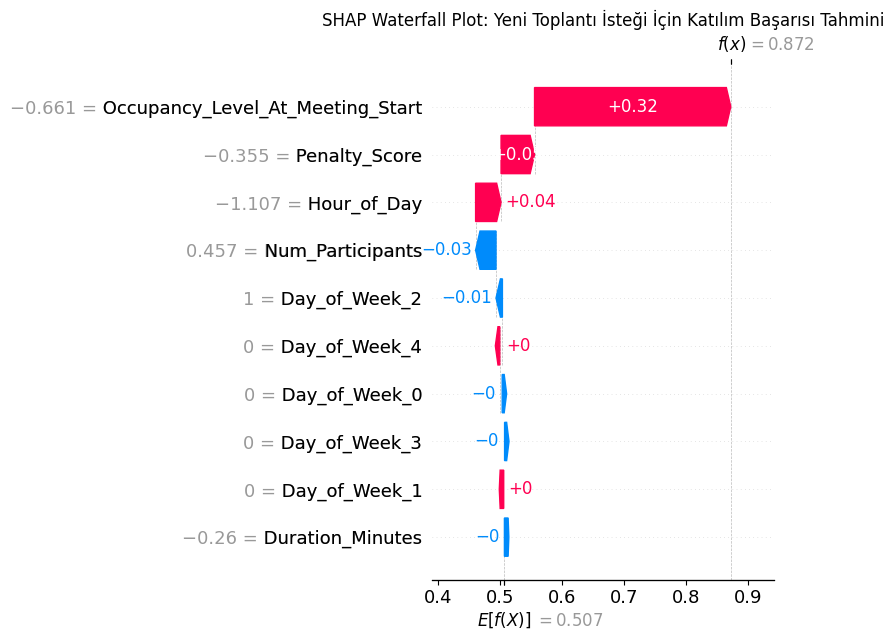

In [31]:
# SHAP Waterfall Plot ile görselleştirme
# Pozitif sınıf için SHAP değerlerini kullanıyoruz (shap_values[:, 1])

import matplotlib.pyplot as plt

new_meeting_processed_series = pd.Series(new_meeting_processed[0], index=feature_names)

# Waterfall plot, tek bir tahminin nasıl yapıldığını gösterir.
# `features` parametresi feature isimlerini almak için kullanılır.
fig = plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[0, :, 1], base_values=expected_value, data=new_meeting_processed_series.values, feature_names=feature_names), show=False)
plt.title('SHAP Waterfall Plot: Yeni Toplantı İsteği İçin Katılım Başarısı Tahmini')
plt.tight_layout()
plt.show()

#### SHAP Waterfall Plot Yorumu

Yukarıdaki **SHAP Waterfall Plot**, modelimizin belirli bir toplantı isteği için 'Katılım Gerçekleşti Mi' tahminini nasıl yaptığını detaylı bir şekilde görselleştirir:

*   **Base Value (Beklenen Değer):** Plotun en altındaki `E[f(X)]` veya `base_value`, modelin eğitim seti üzerindeki ortalama tahminini temsil eder. Bu, herhangi bir özellik bilgisi olmadan modelin varsayılan tahmini olarak düşünülebilir.
*   **Özellik Katkıları:** Plotun ortasındaki her bir çubuk, ilgili özelliğin (örneğin, `Occupancy_Level_At_Meeting_Start`, `Penalty_Score`) modelin tahminini Base Value'dan nihai `f(X)` değerine doğru ne kadar değiştirdiğini gösterir.
    *   **Kırmızı Çubuklar:** Kırmızı renkle gösterilen özellikler, toplantının başarı olasılığını artırma yönünde katkıda bulunmuştur.
    *   **Mavi Çubuklar:** Mavi renkle gösterilen özellikler, toplantının başarı olasılığını azaltma yönünde katkıda bulunmuştur.
    *   Çubuğun uzunluğu, özelliğin katkısının büyüklüğünü gösterir.
*   **f(X) (Model Çıktısı):** Plotun en üstündeki `f(X)` veya `output_value`, tüm özelliklerin katkısı toplandıktan sonraki nihai model tahminini (log-odds cinsinden) veya dönüştürülmüş olasılık değerini gösterir. Bu değer, `success_probability` değişkeninde gördüğümüz olasılık değeriyle ilişkilidir.

Bu görselleştirme sayesinde, örneğin, 'Occupancy_Level_At_Meeting_Start' değerinin düşük olması (kırmızı çubuk), toplantının başarı olasılığını artırırken, 'Penalty_Score'un yüksek olması (mavi çubuk) bu olasılığı azaltabilir. Waterfall Plot, özelliklerin sırayla nasıl birikerek nihai tahmini oluşturduğunu net bir şekilde göstererek, modelin kararlarının ardındaki adımları daha anlaşılır kılar.

<!-- Bu hücrenin içeriği, SHAP Waterfall Plot açıklaması ile değiştirildiği için kaldırıldı. -->

#### Özellik Önem Derecesi Görselleştirmesi (Feature Importance)

Eğittiğimiz Random Forest modelinin, toplantı katılımını tahmin etmede hangi özelliklerin daha önemli olduğunu görmek için özellik önem derecelerini görselleştireceğiz. Bu, modelin kararlarını anlamamıza ve potansiyel olarak özellik mühendisliği adımlarını iyileştirmemize yardımcı olabilir.

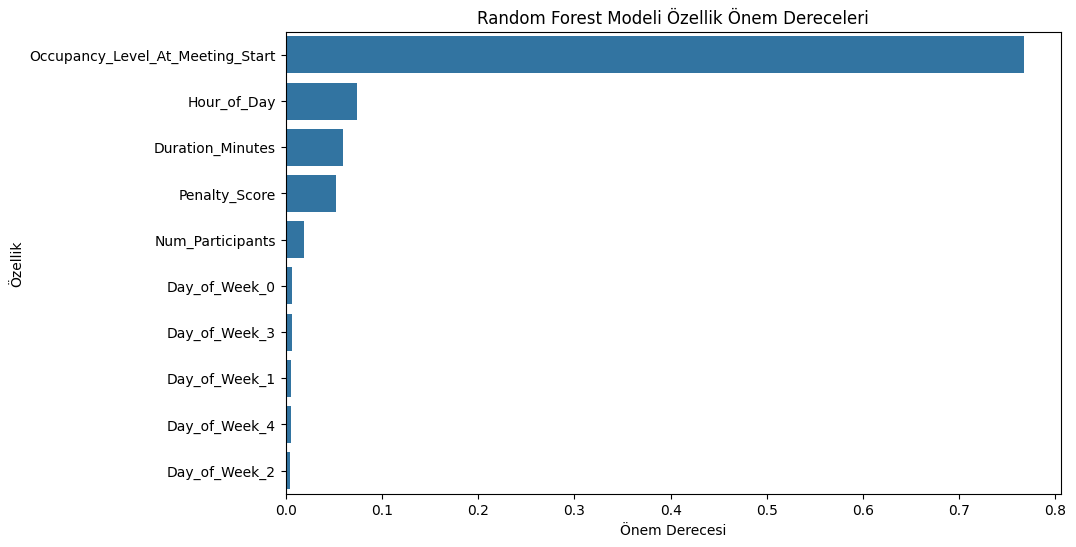

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Özellik önem derecelerini al
feature_importances = model.feature_importances_

# Özellik isimleri ile bir DataFrame oluştur
# feature_names daha önce preprocessor'dan alınmıştı
features_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Önem derecesine göre sırala
features_df = features_df.sort_values(by='Importance', ascending=False)

# Özellik önem derecelerini görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Random Forest Modeli Özellik Önem Dereceleri')
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellik')
plt.show()


#### Karmaşıklık Matrisi Görselleştirmesi (Confusion Matrix)

Modelimizin sınıflandırma performansını daha detaylı incelemek için bir karmaşıklık matrisi (Confusion Matrix) oluşturacağız. Bu matris, doğru pozitifler (True Positives), doğru negatifler (True Negatives), yanlış pozitifler (False Positives) ve yanlış negatifler (False Negatives) hakkında bilgi sağlayarak modelimizin hangi durumlarda başarılı veya başarısız olduğunu anlamamızı sağlar.

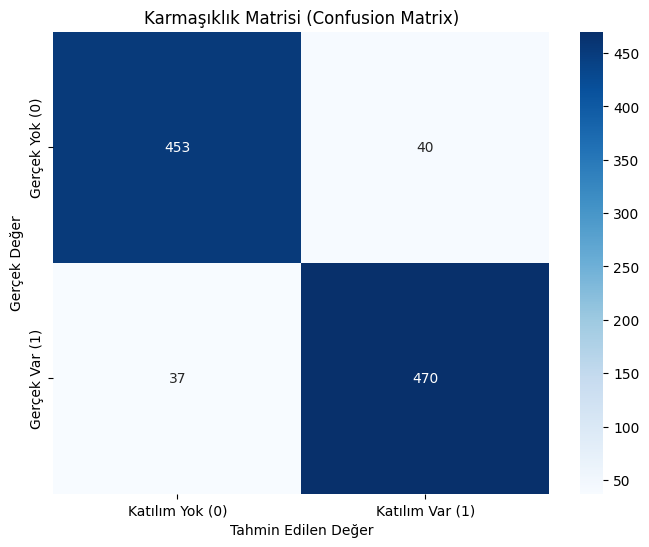

In [33]:
from sklearn.metrics import confusion_matrix

# Karmaşıklık matrisini hesapla
cm = confusion_matrix(y_test, y_pred)

# Karmaşıklık matrisini görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Katılım Yok (0)', 'Katılım Var (1)'],
            yticklabels=['Gerçek Yok (0)', 'Gerçek Var (1)'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Gerçek Değer')
plt.show()


#### Yeni Bir Toplantı İsteği İçin Başarı Şansı Tahmini (predict_proba)

Modelimizi eğittik ve değerlendirdik. Şimdi, modelin pratik uygulamasını göstermek için yeni, varsayımsal bir toplantı isteği oluşturacak ve bu toplantının 'Katılım Gerçekleşti Mi' olma olasılığını tahmin edeceğiz. Bu tahmin, `predict_proba` metodu ile alınacak ve toplantının başarı şansını yüzde olarak ifade edecek.

### Yapay Zeka Ajan Geliştiricisi ve Bilişim Uzmanı Vizyonuyla Hafıza Mimarisinin Katkısı

Bu **Agentic Memory (Ajan Hafızası)** mimarisi, SmartSched sistemine sadece bir veritabanı olmaktan öte, dinamik bir öğrenme ve adaptasyon yeteneği kazandıracaktır. Geleneksel veri yönetimi sistemleri genellikle statik verileri depolarken, bu OOP tabanlı "Hafıza Yöneticisi" şu kritik faydaları sağlayacaktır:

1.  **Dinamik Adaptasyon ve Kişiselleştirme:** Her bir ekip üyesinin kişisel kısıtlamaları (ders saatleri, stajlar, verimlilik alışkanlıkları vb.) zaman içinde öğrenilir ve güncellenir. Bu sayede, sistem 'X' kişisinin perşembe akşamları müsait olmadığını veya 'Y' kişisinin sabahları daha verimsiz olduğunu 'hatırlayarak' toplantı önerilerini buna göre optimize eder.
2.  **Bağlam Odaklı Karar Alma:** LLM'e sadece genel kurallar değil, aynı zamanda belirli bir toplantıya katılacak kişilere özel, özetlenmiş ve ilgili kısıtlamalar sunulur. Bu, LLM'in daha doğru ve bağlama duyarlı toplantı zamanları önermesini sağlar.
3.  **Sistemik Çeviklik:** Modüler ve OOP yapısı sayesinde, yeni kısıtlama tipleri veya kullanıcı profilleri kolayca eklenebilir veya mevcut yapı güncellenebilir. Bu esneklik, sistemin değişen iş gereksinimlerine veya kullanıcı davranışlarına hızla adapte olmasına olanak tanır.
4.  **Kalıcılık ve Güvenilirlik:** SQLite gibi lokal bir veritabanı altyapısı, verilerin oturumlar arasında kaybolmamasını sağlar. Bu, uzun vadeli öğrenme ve tutarlı performans için kritik öneme sahiptir.
5.  **LLM Yükünü Azaltma:** Karmaşık kısıtlama yönetimi ve bağlam oluşturma işleri, LLM'in üzerinden alınarak 'Hafıza Yöneticisi'ne devredilir. LLM, sadece optimize edilmiş ve özetlenmiş bağlam üzerinden mantık yürütür, bu da modelin daha verimli ve odaklı çalışmasını sağlar.

Bu mimari, SmartSched'i statik bir araçtan, dinamik ve akıllı bir asistan haline getirerek, toplantı planlama sürecini insan odaklı ve sorunsuz bir deneyime dönüştürecektir.

### Aşama 3: Dinamik Hafıza ve Profil Yönetimi (Agentic Memory Management)

Bu bölümde, SmartSched projesi için bir 'Ajan Hafızası' mimarisi oluşturacağız. Bu hafıza, ekip üyelerinin kişisel kısıtlamalarını ve tercihlerini kalıcı olarak depolayacak, yönetebilecek ve toplantı planlama süreçlerinde Büyük Dil Modeli (LLM) için zengin bağlam (context) sağlayacak şekilde tasarlanacaktır.

#### İstekler ve Teknik Beklentiler:

*   **Lokal Veritabanı Altyapısı:** Verileri kalıcı olarak saklayan SQLite tabanlı bir sistem (CRUD - Create, Read, Update, Delete operasyonlarını destekleyen).
*   **SmartSchedMemoryManager Sınıfı (Class):**
    *   `add_constraint(user_id, constraint_text, constraint_type)`: Kullanıcının kısıtlamalarını (zaman bazlı, davranışsal vb.) ekler.
    *   `get_user_profile(user_id)`: Belirli bir kullanıcının tüm kısıtlamalarını çeker.
    *   `build_meeting_context(attendees_list)`: Planlanacak bir toplantıya katılacak kişilerin listesini alıp, sadece bu kişilere ait kısıtlamaları LLM'e girdi sağlayacak derli toplu bir metin formatında (`Prompt Context String`) döndürür.
*   **Örnek Veri Simülasyonu:** Kodu yazdıktan sonra, 3-4 farklı ekip üyesi için çeşitli kişisel tercihleri, ders/staj saatlerini ve uyku/verimlilik alışkanlıklarını sisteme ekleyen örnek bir senaryo çalıştır.

In [34]:
import sqlite3
import os

# Veritabanı dosyasının yolu
DB_FILE = 'smartsched_memory.db'

def initialize_database():
    """SmartSched hafıza veritabanını başlatır ve kısıtlamalar tablosunu oluşturur."""
    conn = None
    try:
        # Deneme 1: Mevcut veritabanına bağlan
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()
        # Tablo var mı kontrol et
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='constraints'")
        if not cursor.fetchone():
            # Tablo yoksa oluştur
            cursor.execute("""
                CREATE TABLE constraints (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    user_id TEXT NOT NULL,
                    constraint_text TEXT NOT NULL,
                    constraint_type TEXT NOT NULL,
                    UNIQUE(user_id, constraint_text, constraint_type)
                )
            """)
            conn.commit()
            print(f"Veritabanı '{DB_FILE}' başlatıldı ve 'constraints' tablosu oluşturuldu.")
        else:
            print(f"Veritabanı '{DB_FILE}' mevcut ve 'constraints' tablosu kontrol edildi.")
    except sqlite3.DatabaseError as e:
        # Veritabanı bozuksa
        print(f"Hata: Veritabanı '{DB_FILE}' bozuk görünüyor: {e}")
        if os.path.exists(DB_FILE):
            os.remove(DB_FILE)
            print(f"Bozuk veritabanı dosyası '{DB_FILE}' silindi.")
        # Yeniden deneme: Bozuk dosya silindikten sonra yeni bir veritabanı oluştur
        try:
            conn = sqlite3.connect(DB_FILE)
            cursor = conn.cursor()
            cursor.execute("""
                CREATE TABLE constraints (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    user_id TEXT NOT NULL,
                    constraint_text TEXT NOT NULL,
                    constraint_type TEXT NOT NULL,
                    UNIQUE(user_id, constraint_text, constraint_type)
                )
            """)
            conn.commit()
            print(f"Yeni veritabanı '{DB_FILE}' başarıyla oluşturuldu ve 'constraints' tablosu hazır.")
        except sqlite3.Error as e_retry:
            print(f"Yeniden veritabanı oluşturulurken hata oluştu: {e_retry}")
            if conn:
                conn.close()
            conn = None
    except sqlite3.Error as e:
        print(f"Veritabanı işlemleri sırasında hata oluştu: {e}")
        if conn:
            conn.close()
        conn = None
    finally:
        if conn and hasattr(conn, 'in_transaction') and conn.in_transaction:
            conn.close() # Close connection if it's still open after the error, but not committed
        elif conn:
            conn.close()

# Veritabanını başlat
initialize_database()

Veritabanı 'smartsched_memory.db' mevcut ve 'constraints' tablosu kontrol edildi.


In [35]:
import re # Regex for constraint parsing

class SmartSchedMemoryManager:
    """
    SmartSched projesi için dinamik bir hafıza yöneticisi sınıfı.
    Kullanıcı kısıtlamalarını yönetir ve LLM için bağlam oluşturur.
    """
    def __init__(self, db_file='smartsched_memory.db'):
        self.db_file = db_file
        self._connect()

    def _connect(self):
        """Veritabanı bağlantısını kurar."""
        try:
            self.conn = sqlite3.connect(self.db_file)
            self.conn.row_factory = sqlite3.Row # Sütun isimleriyle erişim için
            self.cursor = self.conn.cursor()
        except sqlite3.Error as e:
            print(f"Veritabanına bağlanırken hata oluştu: {e}")
            self.conn = None
            self.cursor = None

    def _close(self):
        """Veritabanı bağlantısını kapatır."""
        if self.conn:
            self.conn.close()

    def add_constraint(self, user_id, constraint_text, constraint_type):
        """
        Belirli bir kullanıcı için yeni bir kısıtlama ekler.
        Yinelenen kısıtlamaları önler.
        """
        if not self.conn:
            print("Hata: Veritabanı bağlantısı mevcut değil.")
            return False
        try:
            self.cursor.execute("""
                INSERT INTO constraints (user_id, constraint_text, constraint_type)
                VALUES (?, ?, ?)
            """, (user_id, constraint_text, constraint_type))
            self.conn.commit()
            # print(f"'{user_id}' kullanıcısı için yeni kısıtlama eklendi: '{constraint_text}' ({constraint_type})")
            return True
        except sqlite3.IntegrityError:
            # print(f"Uyarı: '{user_id}' kullanıcısı için '{constraint_text}' kısıtlaması zaten mevcut.")
            return False
        except sqlite3.Error as e:
            print(f"Kısıtlama eklenirken hata oluştu: {e}")
            return False

    def get_user_profile(self, user_id):
        """
        Belirli bir kullanıcının tüm kısıtlamalarını döndürür.
        """
        if not self.conn:
            print("Hata: Veritabanı bağlantısı mevcut değil.")
            return []
        try:
            self.cursor.execute(
                "SELECT constraint_text, constraint_type FROM constraints WHERE user_id = ?",
                (user_id,)
            )
            return self.cursor.fetchall()
        except sqlite3.Error as e:
            print(f"Kullanıcı profili alınırken hata oluştu: {e}")
            return []

    def _parse_time_constraint(self, constraint_text, meeting_start, meeting_end):
        """
        Kısıtlama metnini ayrıştırır ve toplantı zamanlarıyla çakışma olup olmadığını kontrol eder.
        Bir ceza puanı döndürür.
        """
        penalty = 0
        meeting_day_of_week = meeting_start.weekday() # Pazartesi 0, Pazar 6

        # Zaman aralığı kalıbı (örn: (HH:MM-HH:MM))
        time_range_pattern = re.compile(r'(\d{2}:\d{2})-(\d{2}:\d{2})')
        time_ranges = time_range_pattern.findall(constraint_text)

        # Gün isimleri kontrolü
        days_tr = {
            'Pazartesi': 0, 'Salı': 1, 'Çarşamba': 2, 'Perşembe': 3, 'Cuma': 4,
            'Cumartesi': 5, 'Pazar': 6
        }

        # Hangi günler için kısıtlamanın geçerli olduğunu bul
        applies_to_today = False
        for day_name, day_idx in days_tr.items():
            if day_name in constraint_text and meeting_day_of_week == day_idx:
                applies_to_today = True
                break
        if 'Hafta içi her gün' in constraint_text and meeting_day_of_week < 5: # Hafta içi
            applies_to_today = True
        if 'her gün' in constraint_text and 'Hafta içi' not in constraint_text:
             applies_to_today = True # 'her gün' ama 'Hafta içi' belirtilmemişse her gün geçerli

        # Eğer kısıtlama bu güne aitse ve zaman aralığı varsa
        if applies_to_today and time_ranges:
            for tr_start_str, tr_end_str in time_ranges:
                try:
                    tr_start_hour, tr_start_minute = map(int, tr_start_str.split(':'))
                    tr_end_hour, tr_end_minute = map(int, tr_end_str.split(':'))

                    constraint_start_dt = meeting_start.replace(hour=tr_start_hour, minute=tr_start_minute, second=0, microsecond=0)
                    constraint_end_dt = meeting_start.replace(hour=tr_end_hour, minute=tr_end_minute, second=0, microsecond=0)

                    # Çakışma kontrolü
                    if (meeting_start < constraint_end_dt and meeting_end > constraint_start_dt):
                        # Çakışan süreyi hesapla (dakika cinsinden)
                        overlap_start = max(meeting_start, constraint_start_dt)
                        overlap_end = min(meeting_end, constraint_end_dt)
                        overlap_minutes = (overlap_end - overlap_start).total_seconds() / 60

                        # Çakışan her dakika için küçük bir ceza
                        penalty += overlap_minutes * 0.5 # Her dakika için 0.5 puan

                        # Tamamen çakışan veya büyük çakışan durumlar için ek ceza
                        if overlap_minutes >= (meeting_end - meeting_start).total_seconds() / 60 * 0.5: # Toplantının %50'sinden fazlası çakışıyorsa
                            penalty += 5

                except ValueError:
                    # Zaman formatı hatası olursa pas geç
                    pass

        # 'Sabah 09:00 toplantılarını tercih etmez' gibi spesifik saat tercihleri
        if 'Sabah 09:00 toplantılarını tercih etmez' in constraint_text and applies_to_today:
            if meeting_start.hour == 9:
                penalty += 10 # Yüksek tercih ihlali

        # 'Öğle yemeği arasına (12:00-13:00) toplantı koymamayı tercih eder'
        if 'Öğle yemeği arasına' in constraint_text and '(12:00-13:00)' in constraint_text and applies_to_today:
            lunch_start = meeting_start.replace(hour=12, minute=0)
            lunch_end = meeting_start.replace(hour=13, minute=0)
            if (meeting_start < lunch_end and meeting_end > lunch_start):
                penalty += 7 # Öğle yemeği tercihi ihlali

        return penalty

    def calculate_penalty_score(self, attendee_id, meeting_start_time, meeting_end_time):
        """
        Belirli bir katılımcı için verilen toplantı zamanlarına göre ceza puanı hesaplar.
        """
        total_penalty = 0
        profile = self.get_user_profile(attendee_id)

        for constraint_text, constraint_type in profile:
            if constraint_type == 'Zaman Bazlı' or constraint_type == 'Tercih':
                total_penalty += self._parse_time_constraint(constraint_text, meeting_start_time, meeting_end_time)
            elif constraint_type == 'Davranışsal':
                # Davranışsal kısıtlamalar için daha genel veya hafif cezalar
                if 'erken saatlerde daha verimli' in constraint_text.lower():
                    if meeting_start_time.hour >= 14: # Öğleden sonra geç saatlerde toplantı ise
                        total_penalty += 2
                elif 'konsantre olamaz' in constraint_text.lower():
                    # Bu tür kısıtlamalar genellikle dış faktörlere bağlıdır. Toplantı konumu gibi bilgiye ihtiyaç duyar.
                    # Şimdilik sabit bir küçük ceza verebiliriz veya dışarıda bırakabiliriz.
                    total_penalty += 1 # Hafif bir ceza

        return total_penalty

    def build_meeting_context(self, attendees_list):
        """
        Verilen katılımcı listesi için tüm kısıtlamaları toplar ve LLM'e uygun bir metin formatında döndürür.
        """
        if not self.conn:
            print("Hata: Veritabanı bağlantısı mevcut değil.")
            return ""

        context_string = "Toplantı katılımcıları için önemli kısıtlamalar ve tercihler:\n\n"
        all_constraints = {}

        try:
            # Katılımcıların kısıtlamalarını al
            # SQL sorgusunda IN operatörü için güvenli parametre geçişi
            placeholders = ', '.join('?' * len(attendees_list))
            query = f"SELECT user_id, constraint_text, constraint_type FROM constraints WHERE user_id IN ({placeholders})"
            self.cursor.execute(query, attendees_list)
            constraints_data = self.cursor.fetchall()

            for row in constraints_data:
                user_id = row['user_id']
                constraint_text = row['constraint_text']
                constraint_type = row['constraint_type']
                if user_id not in all_constraints:
                    all_constraints[user_id] = []
                all_constraints[user_id].append(f"- {constraint_text} (Tip: {constraint_type})")

            if not all_constraints:
                context_string += "Hiçbir katılımcı için kayıtlı kısıtlama bulunmamaktadır."
            else:
                for user_id, cons_list in all_constraints.items():
                    context_string += f"[{user_id}]:\n"
                    context_string += "\n".join(cons_list)
                    context_string += "\n\n"

        except sqlite3.Error as e:
            print(f"Toplantı bağlamı oluşturulurken hata oluştu: {e}")
            context_string = "LLM için bağlam oluşturulurken bir hata oluştu."

        return context_string.strip()

    def __del__(self):
        """Nesne yok edildiğinde veritabanı bağlantısını kapatır."""
        self._close()

#### Örnek Veri Simülasyonu ve Kullanım

Şimdi `SmartSchedMemoryManager` sınıfımızı kullanarak birkaç örnek kullanıcı profili oluşturacak ve kısıtlamalar ekleyeceğiz. Ardından, örnek bir toplantı için LLM'e sağlanacak bağlam metnini (`build_meeting_context`) nasıl oluşturduğumuzu göstereceğiz.

In [36]:
# Hafıza yöneticisi örneği oluşturma
memory_manager = SmartSchedMemoryManager()

# ---- Ekip Üyeleri İçin Kısıtlamalar Ekleme ----
print("\n--- Kısıtlamalar Ekleniyor ---")
# Alice
memory_manager.add_constraint('Alice', 'Perşembe akşamları (18:00-20:00) stajı var', 'Zaman Bazlı')
memory_manager.add_constraint('Alice', 'Cuma sabahları (09:00-10:00) proje toplantısı var', 'Zaman Bazlı')
memory_manager.add_constraint('Alice', 'Sabahları erken saatlerde daha verimli', 'Davranışsal')

# Bob
memory_manager.add_constraint('Bob', 'Salı ve Perşembe öğleden sonraları (14:00-16:00) dersi var', 'Zaman Bazlı')
memory_manager.add_constraint('Bob', 'Öğle yemeği arasına (12:00-13:00) toplantı koymamayı tercih eder', 'Tercih')

# Charlie
memory_manager.add_constraint('Charlie', 'Pazartesi sabahları (09:00-11:00) yoğun odaklanma gerektiren işi var', 'Zaman Bazlı')
memory_manager.add_constraint('Charlie', 'Cuma günleri erken çıkabilir (16:00 sonrası müsait değil)', 'Zaman Bazlı')
memory_manager.add_constraint('Charlie', 'Gürültülü ortamlarda konsantre olamaz', 'Davranışsal')

# David
memory_manager.add_constraint('David', 'Hafta içi her gün 17:00 sonrası spor salonunda', 'Zaman Bazlı')
memory_manager.add_constraint('David', 'Sabah 09:00 toplantılarını tercih etmez', 'Tercih')


# ---- Kullanıcı Profili Görüntüleme ----
print("\n--- Alice'in Profili ---")
alice_profile = memory_manager.get_user_profile('Alice')
for cons_text, cons_type in alice_profile:
    print(f"- {cons_text} (Tip: {cons_type})")


# ---- Toplantı Bağlamı Oluşturma ----
print("\n--- Örnek Toplantı İçin Bağlam Metni (LLM'e Girdi) ---")
meeting_attendees = ['Alice', 'Bob', 'Charlie']
meeting_context = memory_manager.build_meeting_context(meeting_attendees)
print(meeting_context)

print("\n--- Sadece Kayıtlı Olmayan Katılımcılar İçin Bağlam (Örnek) ---")
meeting_attendees_unregistered = ['Grace', 'Frank']
meeting_context_unregistered = memory_manager.build_meeting_context(meeting_attendees_unregistered)
print(meeting_context_unregistered)


# Veritabanı bağlantısını kapat (otomatik __del__ ile de kapanır ancak açıkça çağırmak iyidir)
memory_manager._close()



--- Kısıtlamalar Ekleniyor ---

--- Alice'in Profili ---
- Cuma sabahları (09:00-10:00) proje toplantısı var (Tip: Zaman Bazlı)
- Perşembe akşamları (18:00-20:00) stajı var (Tip: Zaman Bazlı)
- Sabahları erken saatlerde daha verimli (Tip: Davranışsal)

--- Örnek Toplantı İçin Bağlam Metni (LLM'e Girdi) ---
Toplantı katılımcıları için önemli kısıtlamalar ve tercihler:

[Alice]:
- Cuma sabahları (09:00-10:00) proje toplantısı var (Tip: Zaman Bazlı)
- Perşembe akşamları (18:00-20:00) stajı var (Tip: Zaman Bazlı)
- Sabahları erken saatlerde daha verimli (Tip: Davranışsal)

[Bob]:
- Salı ve Perşembe öğleden sonraları (14:00-16:00) dersi var (Tip: Zaman Bazlı)
- Öğle yemeği arasına (12:00-13:00) toplantı koymamayı tercih eder (Tip: Tercih)

[Charlie]:
- Cuma günleri erken çıkabilir (16:00 sonrası müsait değil) (Tip: Zaman Bazlı)
- Gürültülü ortamlarda konsantre olamaz (Tip: Davranışsal)
- Pazartesi sabahları (09:00-11:00) yoğun odaklanma gerektiren işi var (Tip: Zaman Bazlı)

--- Sadece Kay